In [1]:
import os
os.environ["JAX_PLATFORMS"] = 'cpu'
import jax.numpy as jnp
import jax 
import numpy as np
from utils import (
                  syn_group_id_paths_for_sem_data,
                  sem_ids_path,
                  syn_syn_ids_path,
                  collect_data,
                   torch_to_jax,
                   clip,
                   flatten_tokens_features,
                   depths,
                   reduce_list_half_preserve_extremes,
                   remove_syn_group_averages,
                   load_and_subtract_syn_group_averages,
                   )
from geometry import normalized_L2_distance
from datapaths import * 
import matplotlib.pyplot as plt
from torch import from_numpy


/home/acevedo/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
min_token_length = 6
n_tokens = min_token_length
n_files = 21
model_name = 'qwen7b'
precision = 32
data_var = 'sem'
avg_tokens = 0

input_path_A = input_paths['english'][model_name]['matching']['0'][data_var]
input_path_B = input_paths['english'][model_name]['matching']['1'][data_var]

In [3]:
all_activations_A = collect_data(input_path_A, 
            min_token_length, 
            n_files,
            model_name,
            avg_tokens,
            )
all_activations_B = collect_data(input_path_B, 
            min_token_length, 
            n_files,
            model_name,
            avg_tokens,
            )

qwen7b dtype: torch.bfloat16


Collect File: 100%|██████████| 21/21 [00:02<00:00, 10.29it/s]


all_hidden_states["layer_0"].shape=torch.Size([2018, 6, 3584])
importing took 0.05368196169535319 m
qwen7b dtype: torch.bfloat16


Collect File: 100%|██████████| 21/21 [00:01<00:00, 16.27it/s]


all_hidden_states["layer_0"].shape=torch.Size([2018, 6, 3584])
importing took 0.042177708943684895 m


In [4]:
def preprocessing(all_activations, layers, space_index, syntax_center_flag, global_center_flag):

  center_A_flag = syntax_center_flag
  center_B_flag = center_A_flag
  removal_method = 'subtraction'
  random_center_type = None

  syn_syn_indices = jnp.array(np.loadtxt(syn_syn_ids_path,dtype=int),dtype=jnp.int32) # filtering data to ALSO have their syntax group in space B

  act = {}
  centers = {}
  global_centers = {}

  for layer in layers:
      # loading data

      _all_activations = all_activations[f"layer_{layer}"]
      act[str(layer)] = torch_to_jax(_all_activations[:,-n_tokens:,:],precision)
      act[str(layer)] = flatten_tokens_features(act[str(layer)])

      # globally centering data
      if global_center_flag:
          global_centers[str(layer)] = jnp.mean(act[str(layer)],axis=0)
          act[str(layer)] = act[str(layer)] - jnp.broadcast_to(global_centers[str(layer)],act[str(layer)].shape)
      else:
         global_centers[str(layer)] = None
      
      # keeping data with syn_centers
      sem_ids = jnp.array(np.loadtxt(sem_ids_path,dtype=int),dtype=jnp.int32) # filtering data to have their syntax group in space A 
      act[str(layer)] = act[str(layer)][sem_ids]

      # loading syntax_centers
      centers_folder = f"/home/acevedo/syn-sem/results/global_centering_0/spaces_AB/similarity_fn_normalized_L2_distance/precision_32/language_english/data_var_syn/modelA_qwen7b/modelB_qwen7b/match_var_matching/n_files_21/min_token_length_6/similarities/centers_syn/Nbits_0/n_tokens_{n_tokens}/avg_tokens_0/batch_shuffle_0/layer_A_{layer}/layer_B_{layer}/"
      centers[str(layer)] = jnp.array(np.load(os.path.join(centers_folder, f'syn_centers_{space_index}.npy'))).astype(jnp.float32) #(num_groups,E)
  
      # # # global_centering syntax centers...
      # if global_center_flag: 
      #     centers[str(layer)] = centers[str(layer)] - jnp.broadcast_to(global_centers[str(layer)],centers[str(layer)].shape)
      
      if syntax_center_flag:
        if space_index == 'A':
          act[str(layer)] = load_and_subtract_syn_group_averages(act[str(layer)],syn_group_id_paths_for_sem_data[space_index],centers_folder,center_A_flag,removal_method,random_center_type,global_centers[str(layer)],space_index)
      act[str(layer)] = act[str(layer)][syn_syn_indices]

      if space_index == 'B':
        act[str(layer)] = act[str(layer)][syn_syn_indices]
        if syntax_center_flag:
          act[str(layer)] = load_and_subtract_syn_group_averages(act[str(layer)],syn_group_id_paths_for_sem_data[space_index],centers_folder,center_B_flag,removal_method,random_center_type,global_centers[str(layer)],space_index)
  # print(f'{act[str(layer)].shape=}')
  # print(f'{centers[str(layer)].shape=}')
  # if global_center_flag:
  #   print(f'{global_centers[str(layer)].shape=}')
  print(f'{act[str(layer)].mean()=}')
  return act, centers, global_centers

loading and subtracting syn group averages
act[str(layer)].mean()=Array(-8.461454, dtype=float32)
loading and subtracting syn group averages
act[str(layer)].mean()=Array(-19.06891, dtype=float32)
act[str(layer)].mean()=Array(26.369911, dtype=float32)
act[str(layer)].mean()=Array(-6.7457614, dtype=float32)


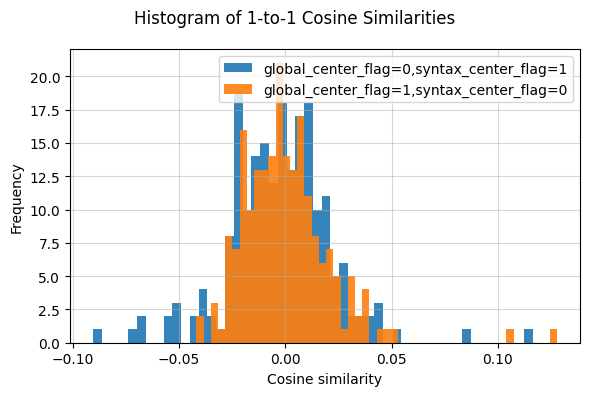

In [5]:
layers = [14] # reduce_list_half_preserve_extremes(np.arange(1,depths[model_name]+1,dtype=int))
layer = str(layers[0])

plt.figure(figsize=(6,4))

for global_center_flag in [0,1]:
  syntax_center_flag = 0 if global_center_flag else 1
  # syntax_center_flag = 1

  act_A, centers_A, global_centers_A = preprocessing(all_activations_A, layers, space_index='A', syntax_center_flag=syntax_center_flag,global_center_flag=global_center_flag)
  act_B, centers_B, global_centers_B = preprocessing(all_activations_B, layers, space_index='B', syntax_center_flag=syntax_center_flag,global_center_flag=global_center_flag)

  for batch_shuffle_B in [0]:
    A = act_A[layer]  # shape (N_samples, N_features)
    B = act_B[layer]  # shape (N_samples, N_features)
    
    if batch_shuffle_B:
      key = jax.random.PRNGKey(9999)  # seed
      perm = jax.random.permutation(key, B.shape[0])  # permutes indices 0..N_samples-1
      B = B[perm]
    # Compute rowwise cosine similarities
    numerator = jnp.sum(A * B, axis=1)
    denominator = jnp.linalg.norm(A, axis=1) * jnp.linalg.norm(B, axis=1)
    cosine_sims = numerator / (denominator + 1e-8)  # shape (N_samples,)

    cosine_sims_np = jnp.asarray(cosine_sims)  # JAX -> numpy view

    lbl = f'{global_center_flag=}'
    if batch_shuffle_B:
      lbl += f',{batch_shuffle_B=}'
    lbl += f',{syntax_center_flag=}'
    plt.hist(cosine_sims_np, bins=50, alpha=0.9, label=lbl)

plt.xlabel("Cosine similarity")
plt.ylabel("Frequency")
plt.suptitle("Histogram of 1-to-1 Cosine Similarities")
# plt.title(f"{syntax_center_flag=}")
plt.grid(alpha=0.5)
plt.tight_layout()
plt.legend()
plt.show()


loading and subtracting syn group averages
act[str(layer)].mean()=Array(-8.461454, dtype=float32)
loading and subtracting syn group averages
act[str(layer)].mean()=Array(-19.06891, dtype=float32)
act[str(layer)].mean()=Array(26.369911, dtype=float32)
act[str(layer)].mean()=Array(-6.7457614, dtype=float32)


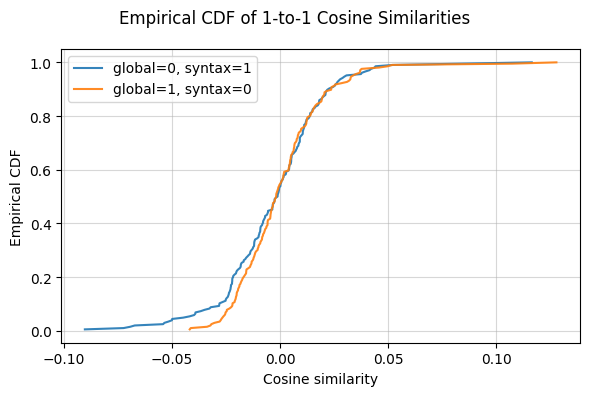

In [6]:
plt.figure(figsize=(6,4))

for global_center_flag in [0,1]:
    syntax_center_flag = 0 if global_center_flag else 1

    act_A, centers_A, global_centers_A = preprocessing(
        all_activations_A, layers, space_index='A',
        syntax_center_flag=syntax_center_flag, global_center_flag=global_center_flag
    )
    act_B, centers_B, global_centers_B = preprocessing(
        all_activations_B, layers, space_index='B',
        syntax_center_flag=syntax_center_flag, global_center_flag=global_center_flag
    )

    for batch_shuffle_B in [0]:
        A = act_A[layer]  # shape (N_samples, N_features)
        B = act_B[layer]  # shape (N_samples, N_features)

        if batch_shuffle_B:
            key = jax.random.PRNGKey(9999)
            perm = jax.random.permutation(key, B.shape[0])
            B = B[perm]

        # Compute rowwise cosine similarities
        numerator = jnp.sum(A * B, axis=1)
        denominator = jnp.linalg.norm(A, axis=1) * jnp.linalg.norm(B, axis=1)
        cosine_sims = numerator / (denominator + 1e-8)

        cosine_sims_np = np.asarray(cosine_sims)  # JAX -> numpy

        # --- empirical CDF ---
        x = np.sort(cosine_sims_np)
        y = np.arange(1, len(x)+1) / len(x)

        lbl = f'global={global_center_flag}, syntax={syntax_center_flag}'
        if batch_shuffle_B:
            lbl += f',shuffle={batch_shuffle_B}'
        plt.plot(x, y, label=lbl, alpha=0.9)

plt.xlabel("Cosine similarity")
plt.ylabel("Empirical CDF")
plt.suptitle("Empirical CDF of 1-to-1 Cosine Similarities")
plt.grid(alpha=0.5)
plt.tight_layout()
plt.legend()
plt.show()


loading and subtracting syn group averages
act[str(layer)].mean()=Array(-32322.48, dtype=float32)


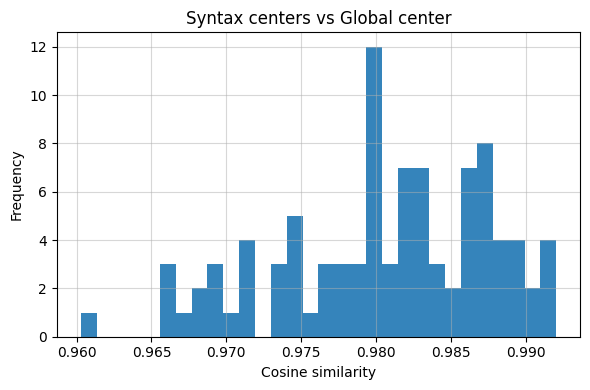

In [7]:
global_center_flag = 1
syntax_center_flag = 1

act_A, centers_A, global_centers_A = preprocessing(
    all_activations_A, layers, space_index='A',
    syntax_center_flag=syntax_center_flag,
    global_center_flag=global_center_flag
)

centers = centers_A[layer]              # (n_groups, n_features)
global_center = global_centers_A[layer] # (n_features,)

numerator = jnp.sum(centers * global_center, axis=1)
denominator = jnp.linalg.norm(centers, axis=1) * jnp.linalg.norm(global_center)
cosine_sims_centers = numerator / (denominator + 1e-8)

plt.figure(figsize=(6,4))
plt.hist(jnp.asarray(cosine_sims_centers), bins=30, alpha=0.9)
plt.xlabel("Cosine similarity")
plt.ylabel("Frequency")
plt.title("Syntax centers vs Global center")
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()


In [8]:
import numpy as np

group_ids_A_path = "/home/acevedo/syn-sem/datasets/txt/sem/second/matching/english/all_group_ids_A.txt"
syn_syn_indices = jnp.array(np.loadtxt(syn_syn_ids_path,dtype=int),dtype=jnp.int32) # filtering data to ALSO have their syntax group in space B
group_ids_A = jnp.array(np.loadtxt(group_ids_A_path),dtype=jnp.int32)[syn_syn_indices]
group_ids_A

Array([88, 22, 71, 44, 63,  5,  7, 42, 64, 13, 47, 59, 64,  9, 88, 44, 56,
       34, 67, 64, 87, 56,  6,  9,  4, 63, 11, 10,  8, 87,  8, 44, 44, 30,
       88,  9, 80,  5, 67,  5, 87, 87, 59, 80, 59, 67, 80, 59, 42, 42, 47,
       44,  5, 10, 69, 56, 64, 13, 22, 47, 59, 59, 47, 10, 88, 47, 22,  9,
        8, 13, 47, 58,  5,  6, 48, 56, 56, 35, 59, 87, 88, 69, 59, 21, 59,
       42, 87, 59, 13,  2, 59, 10, 67, 87, 20, 13, 30, 30, 10, 32, 44, 64,
       13, 59, 30, 59, 58, 87, 84, 36, 67, 58, 10,  6, 42,  8, 13, 59, 67,
       59, 88, 92,  2,  8, 10, 59, 67, 90, 59, 87, 17, 48, 58, 42,  6, 44,
        9, 67,  8, 19, 59, 49, 47, 30,  8,  8, 59, 63,  4, 59, 87, 59,  8,
       64, 59,  8, 49,  2,  5, 64, 44, 69,  4, 88, 63, 42, 67, 42, 64, 42,
       59, 59, 47, 42, 12, 87, 44, 22, 10, 44, 42, 63,  5, 87,  5, 47, 10,
       77, 42, 88, 80, 42, 56, 47, 63, 44,  6, 69,  2, 77, 92, 69, 59, 88,
       88, 87], dtype=int32)

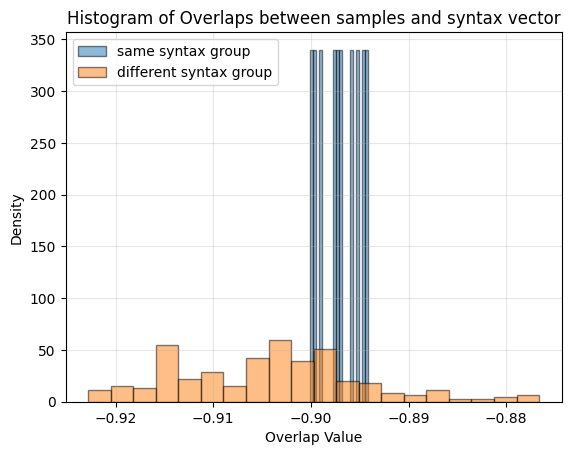

In [9]:
group_id = 8
group_indices = jnp.where(group_ids_A == group_id)[0]
all_indices = jnp.arange(len(group_ids_A), dtype=jnp.int32)
complementary_indices = all_indices[~jnp.isin(all_indices, group_indices)]
center = centers_A[str(layers[0])][group_id]
group_indices

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
bins = 20

for plot_id, indices in enumerate([group_indices, complementary_indices]):

          overlaps = jnp.zeros(shape=(len(indices),))
          for enum_i,i in enumerate(indices):
              overlaps = overlaps.at[enum_i].set(
                  jnp.dot(act_A[str(layers[0])][i] / jnp.linalg.norm(act_A[str(layers[0])][i]),
                          center / jnp.linalg.norm(center))
              )

          if len(indices) == len(group_indices):
              label = f'same syntax group'
          elif len(indices) == len(complementary_indices):
              label = 'different syntax group'

          plt.hist(overlaps,
                  bins=bins,
                  color=colors[plot_id],
                  edgecolor='black',
                  alpha=0.5,
                  density=True,
                  label=label)

plt.title('Histogram of Overlaps between samples and syntax vector')
plt.xlabel('Overlap Value')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
